<a href="https://colab.research.google.com/github/g019-expert/BMEN5801_PS1/blob/main/BMEN5801_ps1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/g019-expert/BMEN5801_PS1.git

import os

DATA = 'BMEN5801_PS1/data'
RESULTS = 'BMEN5801_PS1/figures'
os.makedirs(RESULTS, exist_ok=True)
print(sorted(os.listdir(DATA)))

Cloning into 'BMEN5801_PS1'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 19 (delta 0), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 29.92 MiB | 17.36 MiB/s, done.
['ALL_BoneMarrowSmear.png', 'GSE54456_RPKM_samples.csv', 'GSE54456_labels.csv', 'ecg-svt.h5']


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import skimage
import matplotlib.pyplot as plt
from scipy import signal, stats

# given that sampled at same hz for all leads
FS = 977.0 # hz

LIMB = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF']
CHEST = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']


Problem 1

In [3]:
df = pd.read_hdf(f'{DATA}/ecg-svt.h5')

print(df.shape)
print(df.columns.tolist())
print(df['record'].value_counts())
print(df.head())
print(df.index.min(), df.index.max())

(1191633, 13)
['record', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
record
x0025    650620
x0021    541013
Name: count, dtype: int64
  record      I     II    III    aVR    aVL    aVF     V1     V2     V3  \
0  x0021  0.010 -0.053 -0.054  0.044  0.039 -0.044 -0.082 -0.175 -0.295   
1  x0021  0.019 -0.058 -0.064  0.049  0.039 -0.053 -0.087 -0.165 -0.290   
2  x0021  0.019 -0.067 -0.069  0.049  0.049 -0.058 -0.087 -0.170 -0.290   
3  x0021  0.014 -0.063 -0.064  0.044  0.044 -0.044 -0.082 -0.160 -0.290   
4  x0021  0.014 -0.038 -0.044  0.029  0.039 -0.024 -0.087 -0.155 -0.286   

      V4     V5     V6  
0 -0.124 -0.048 -0.024  
1 -0.124 -0.043 -0.029  
2 -0.124 -0.048 -0.034  
3 -0.124 -0.043 -0.029  
4 -0.124 -0.048 -0.034  
0 1191632


x0021: R at 0.176 s, RR = 0.379 s (158.2 bpm)
x0025: R at 0.801 s, RR = 0.528 s (113.7 bpm)


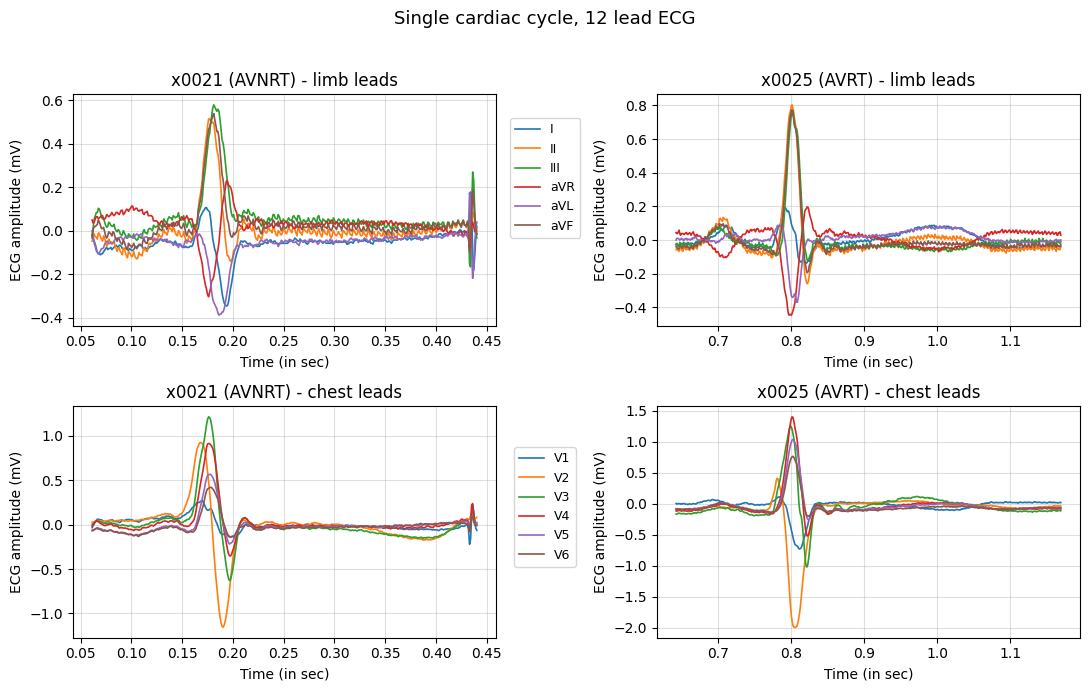

In [4]:
# 1(a) limb leads top, chest leads below (x0021 on left and x0025 right col)

PATIENTS = [('x0021','AVNRT'), ('x0025','AVRT')]

from scipy.signal import find_peaks

fig, axes = plt.subplots(2, 2, figsize=(11, 7))


# return (low, high, r_0, rr) sample bounds around the first clean cardiac cycle
# both x0021 and x0025
def first_beat_window(sig, fs=FS, guard_s=0.05, n_rr=4): # 50 ms power on guard
    x = sig - np.median(sig[:int(5*fs)])
    pk, _ = find_peaks(np.abs(x), height=0.5*np.max(np.abs(x[:int(10*fs)])),
                       distance=int(0.2*fs))
    rr = np.median(np.diff(pk[:n_rr+1])) / fs
    # first beat
    for r0 in pk:
        lo, hi = int(r0 - 0.30*rr*fs), int(r0 + 0.70*rr*fs)
        if lo >= int(guard_s*fs):
            return lo, hi, r0, rr

# locate each patient record
def get_record(df, rec):
  return df.loc[df['record'] == rec].reset_index(drop=True)

for col, (rec, dx) in enumerate(PATIENTS):
    d = get_record(df, rec)
    # lead II timing reference
    lo, hi, r0, rr = first_beat_window(d['II'].values)
    t = np.arange(lo, hi) / FS

    for row, leads in enumerate([LIMB, CHEST]):
        ax = axes[row, col]
        for L in leads:
            v = d[L].values[lo:hi] - np.median(d[L].values[:int(5*FS)])
            ax.plot(t, v, lw=1.2, label=L)
        ax.set_xlabel('Time (in sec)')
        ax.set_ylabel('ECG amplitude (mV)')
        ax.set_title(f'{rec} ({dx}) - {"limb" if row==0 else "chest"} leads')
        ax.grid(True, alpha=0.4)

    print(f'{rec}: R at {r0/FS:.3f} s, RR = {rr:.3f} s ({60/rr:.1f} bpm)')

fig.legend(handles=axes[0,0].get_legend_handles_labels()[0],
           loc='center', bbox_to_anchor=(0.5, 0.74), frameon=True, fontsize=9)
fig.legend(handles=axes[1,0].get_legend_handles_labels()[0],
           loc='center', bbox_to_anchor=(0.5, 0.27), frameon=True, fontsize=9)

fig.suptitle('Single cardiac cycle, 12 lead ECG', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.subplots_adjust(wspace=0.38)
fig.savefig(f'{RESULTS}/p1a_first_beat.png', dpi=200, bbox_inches='tight')
plt.show()

The QRS polarity varies across leads within each patient because the lead porjects the same QRS vector onto a different axis, so the leads near the vector (II, III, aVF) are upright and leads opposing it (aVR, aVL) are negative. And lead perpendicular is close to I.

In [6]:
# 1(b) mean QRS vector in frontal plane for each patient and limb lead for each patient

# positive - negative deflection, referenced from lecture to measure net qrs deflection

LEAD_ANGLE = {'I': 0, 'II': 60, 'III': 120, 'aVR': -150, 'aVL': -30, 'aVF': 90}

def ang_diff(a, b):
    return abs((a - b + 180) % 360 - 180)

def qrs_net_deflection(sig, r0, fs=FS, qrs_half=0.05, pr_win=(0.08, 0.04)):
    # net QRS = positive peak + negative peak
    base = np.median(sig[r0 - int(pr_win[0]*fs): r0 - int(pr_win[1]*fs)])
    qrs = sig[r0 - int(qrs_half*fs): r0 + int(qrs_half*fs)] - base # (base from PR)
    return qrs.max() + qrs.min()

axis_results = {}
for rec, dx in PATIENTS:
    d = get_record(df, rec)
    lo, hi, r0, rr = first_beat_window(d['II'].values)
    net = {L: qrs_net_deflection(d[L].values, r0) for L in LIMB}

    # signs of I and aVF give the quadrant and |net| < 10% of max treated as equiphasic
    tol = 0.1 * max(abs(v) for v in net.values())
    sgn = lambda v: '0' if abs(v) < tol else ('+' if v > 0 else '-')
    I_s, aVF_s = sgn(net['I']), sgn(net['aVF'])
    quadrant = {('+','+'): 'normal (0 to +90)', ('+','-'): 'left (0 to -90)',
                ('-','+'): 'right (+90 to 180)', ('-','-'): 'extreme (-90 to 180)',
                ('0','+'): 'on the +90 border', ('0','-'): 'on the -90 border',
                ('+','0'): 'on the 0 border', ('-','0'): 'on the 180 border'}.get((I_s, aVF_s), 'indeterminate')

    # find lead with largest positive deflection
    tallest = max(LIMB, key=lambda L: net[L])
    equiphasic = min(LIMB, key=lambda L: abs(net[L]))

    # mean QRS vector, using least squares fit of net_k
    th = np.deg2rad([LEAD_ANGLE[L] for L in LIMB])
    A = np.column_stack([np.cos(th), np.sin(th)])
    (vx, vy), *_ = np.linalg.lstsq(A, np.array([net[L] for L in LIMB]), rcond=None)
    axis = np.degrees(np.arctan2(vy, vx))
    aligned = min(LIMB, key=lambda L: ang_diff(axis, LEAD_ANGLE[L]))
    axis_results[rec] = (axis, aligned)

    print(f'{rec} ({dx}) beat at R = {r0/FS:.3f} s')
    for L in LIMB:
        print(f'   {L:>4} ({LEAD_ANGLE[L]:+4d} deg): net QRS = {net[L]:+.3f} mV')
    print(f'I {I_s}, aVF {aVF_s} belongs to {quadrant}')
    print(f'largest positive deflection: {tallest}')
    print(f'most equiphasic: {equiphasic} (axis perpendicular to {LEAD_ANGLE[equiphasic]:+d} deg)')
    print(f'QRS axis = {axis:+.1f} deg, so limb lead that closely aligns with QRS vector is: {aligned}\n')

x0021 (AVNRT) beat at R = 0.176 s
      I (  +0 deg): net QRS = -0.096 mV
     II ( +60 deg): net QRS = +0.528 mV
    III (+120 deg): net QRS = +0.594 mV
    aVR (-150 deg): net QRS = -0.221 mV
    aVL ( -30 deg): net QRS = -0.326 mV
    aVF ( +90 deg): net QRS = +0.588 mV
I -, aVF + belongs to right (+90 to 180)
largest positive deflection: III
most equiphasic: I (axis perpendicular to +0 deg)
QRS axis = +96.8 deg, so limb lead that closely aligns with QRS vector is: aVF

x0025 (AVRT) beat at R = 0.801 s
      I (  +0 deg): net QRS = +0.120 mV
     II ( +60 deg): net QRS = +0.668 mV
    III (+120 deg): net QRS = +0.681 mV
    aVR (-150 deg): net QRS = -0.348 mV
    aVL ( -30 deg): net QRS = -0.276 mV
    aVF ( +90 deg): net QRS = +0.656 mV
I +, aVF + belongs to normal (0 to +90)
largest positive deflection: III
most equiphasic: I (axis perpendicular to +0 deg)
QRS axis = +85.3 deg, so limb lead that closely aligns with QRS vector is: aVF



x0021, QRS axis = +97deg, most closely aligned with lead aVF
x0025, QRS axis = +85deg, most closely aligned with lead aVF

aVR and aVL are both -ive so deplarization heads away from both upper left and upper right leads, and II, III, and aVF all have equal net deflections (within small mV), and thus the axis uses a least square vector fit over all 6 limb leads, and closest alignment is decided with the one whose angle is closest to that vector

In [ ]:
# 1(c)
# lead III for both recrods sampled at same FS, and determine instant HR againt time for whole recording
from scipy import ndimage

